# Classic DFT study notebook

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

Defining sampling rate, samples and functions to be studied

<function matplotlib.pyplot.show(close=None, block=None)>

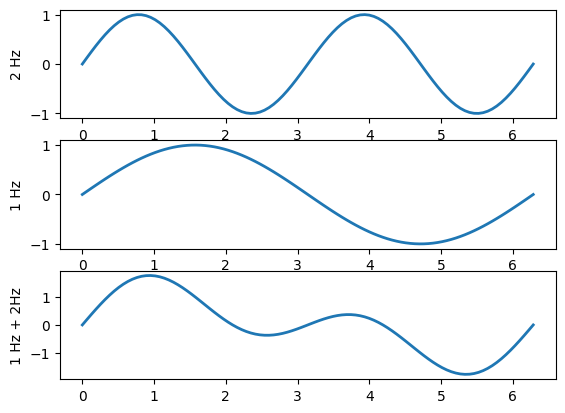

In [6]:
n = 100 # sampling rate = frequency in Hz

x = np.linspace(0, 2*np.pi, n)

f = np.sin(x)
f_2 = np.sin(2*x)

f_3 = f + f_2

fig, ax = plt.subplots(3, 1)

ax[0].plot(x,  f_2, linewidth=2.0)
ax[0].set_ylabel("2 Hz")

ax[1].plot(x,  f, linewidth=2.0)
ax[1].set_ylabel("1 Hz")

ax[2].plot(x,  f_3, linewidth=2.0)
ax[2].set_ylabel("1 Hz + 2Hz")

plt.show

## Discrete Fourier Transform

The Discrete Fourier Transform takes a discrete function in the time domain and takes it to the frequency domain by applying the following summation:

$$X[k] = \sum_{i=0}^{i=N-1}x[k] \cdot \exp(-\frac{2 \pi k i}{N}\cdot j)$$

Lets call
$$w_N = \exp(-\frac{2 \pi}{N}\cdot j)$$

So

$$X[k] = \sum^{i = N-1}_{i = 0}x[k] w_N^{k i}$$

Therefore, we have the following:

$$X[0] = N \cdot x[0]$$
$$X[1] = x[1] + x[1] w_N + x[1] w_N^2 + \ldots x[1]w_N^{N-1}$$
$$X[2] = x[2] + x[2] w_N^2 + x[2] w_N^4 + \ldots x[2]w_N^{2(N-1)}$$
$$\vdots$$
$$X[N-1] = x[N-1] w_N^{N-1} + x[N-1] w_N^{2(N-1)} + \ldots x[N-1] w_N^{(N-1)^2}$$

So we can write the Discrete Fourier Fransform like this:

$$X = W x$$

Where $X \in \mathbb C^{N \times 1}$, $x \in \mathbb R^{N \times 1}$ and $W \in \mathbb C^{N \times N}$ is the matrix

\begin{bmatrix}
    0 & 0 & 0 & 0 & 0 \\
    0 & w_N & w_N^2 & \cdots & w_N^{N-1} \\
    0 & w_N^2 & w_N^4 & \cdots & w_N^{2(N-1)} \\
    0 & \vdots & \vdots & \ddots & \vdots \\
    0 & w_N^{N-1} & w_N^{2(N-1)} & \cdots & w_N^{(N-1)^2}
\end{bmatrix}

In [7]:
def naiveDFT(x):
    N = len(x)

    n = np.arange(N)
    k = n.reshape((N, 1))

    W = np.exp(-2j * np.pi * k * n / N)
    X = x @ W

    return X

def getFrequencyAxis(X, sr):
    N = len(X)
    n = np.arange(N)
    T = N/sr
    freq = n/T
    return freq

Text(0.5, 0, 'Frequency Hz')

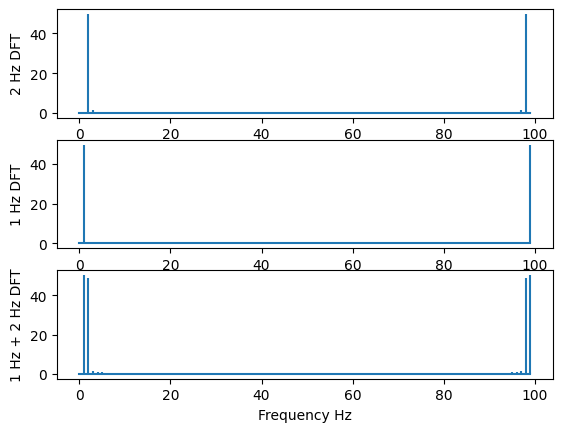

In [8]:
F = naiveDFT(f)
F_2 = naiveDFT(f_2)
F_3 = naiveDFT(f_3)

freq = getFrequencyAxis(F, n)

fig, ax = plt.subplots(3, 1)

ax[0].stem(freq, abs(F_2), markerfmt='', basefmt='')
ax[0].set_ylabel("2 Hz DFT")

ax[1].stem(freq, abs(F), markerfmt='', basefmt='')
ax[1].set_ylabel("1 Hz DFT")

ax[2].stem(freq, abs(F_3), markerfmt='', basefmt='')
ax[2].set_ylabel("1 Hz + 2 Hz DFT")

ax[2].set_xlabel('Frequency Hz')

/tmp/ipykernel_18144/1337646440.py:4: RuntimeWarning: divide by zero encountered in divide
  F_3oneside = F_3[: n//2] / f_oneside
/tmp/ipykernel_18144/1337646440.py:4: RuntimeWarning: invalid value encountered in divide
  F_3oneside = F_3[: n//2] / f_oneside


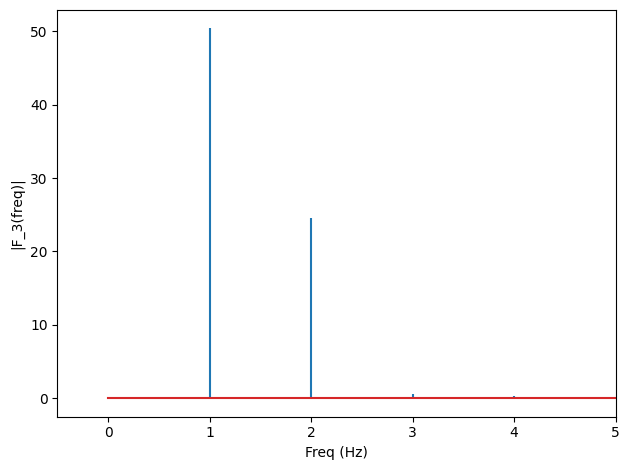

In [9]:
f_oneside = freq[: n//2]

#normalize amplitude
F_3oneside = F_3[: n//2] / f_oneside

plt.stem(f_oneside, abs(F_3oneside),
         markerfmt=" ")
plt.xlabel('Freq (Hz)')
plt.ylabel('|F_3(freq)|')
plt.xlim(-0.5, 5)
plt.tight_layout()
plt.show()


### Performance of naive DFT algorithm is $O(N^2)$

In [10]:
def gen_sig(n):
    '''
      function to generate
      a simple 1D signal with
      different sampling rate (n)
    '''
    ts = 1.0/n
    t = np.arange(0,1,ts)

    freq = 1.
    x = 3*np.sin(2*np.pi*freq*t)
    return x

In [11]:
n = 1

%timeit naiveDFT(gen_sig(n))

10.1 μs ± 146 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [12]:
n = 2000

%timeit naiveDFT(gen_sig(n))

199 ms ± 29.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
n = 4000

%timeit naiveDFT(gen_sig(n))

681 ms ± 120 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
n = 8000

%timeit naiveDFT(gen_sig(n))

2.43 s ± 314 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Fast Fourier Transform FFT